# Optogenetic simulation: watershed + trackpy + top-edge stimulation

Demonstrates the full rtm-pymmcore pipeline using the virtual-microscope optogenetic backend.
- **Segmentation:** Watershed (Gaussian blur → Otsu → distance transform → watershed)
- **Tracking:** Trackpy
- **Stimulation:** Illuminate the top 10 % (y-direction) of each cell with mask dilation

In [1]:
import sys, os
sys.path.insert(0, "/Users/luhin/sync/phd/code/rtm-pymmcore")
sys.path.insert(0, "/Users/luhin/sync/phd/code/virtual-microscope/src")

from virtual_microscope.backends.optogenetic import setup_optogenetic
from rtm_pymmcore.microscope.simulation import UniMMCoreSimulation
import rtm_pymmcore.core.utils as utils

core, sim = setup_optogenetic()
mic = UniMMCoreSimulation(mmc=core)

from virtual_microscope.engine.simulation_bridge import GLOBAL_BRIDGE
engine = GLOBAL_BRIDGE._engine
#engine._time_scale = 0.5

utils.print_configs(core)

Config Groups
└── Channel
    ├── DAPI
    ├── membrane
    └── phase-contrast

## Custom segmentator: Watershed

In [10]:
import numpy as np
from skimage.filters import gaussian, threshold_otsu
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label
from scipy import ndimage
from rtm_pymmcore.segmentation.base import Segmentator


class WatershedSegmentator(Segmentator):
    """Gaussian blur -> Otsu threshold -> distance transform -> watershed."""

    def segment(self, image: np.ndarray) -> np.ndarray:
        blurred = gaussian(image, sigma=3)
        thresh = threshold_otsu(blurred)
        binary = blurred > thresh
        distance = ndimage.distance_transform_edt(binary)
        coords = peak_local_max(distance, min_distance=25, labels=binary)
        markers = np.zeros(distance.shape, dtype=bool)
        markers[tuple(coords.T)] = True
        markers = label(markers)
        return watershed(-distance, markers, mask=binary)

## Custom stimulator: top-edge illumination

In [11]:
from rtm_pymmcore.stimulation.base import Stim
from skimage.morphology import disk, dilation
from skimage.measure import regionprops


class StimTopEdge(Stim):
    """Illuminate the top *fraction* of each cell's y-extent, dilated by disk(3)."""

    def __init__(self, fraction=0.1):
        super().__init__()
        self.use_labels = True
        self.use_imgs = False
        self.fraction = fraction

    def get_stim_mask(self, label_images, metadata=None, img=None):
        labels = label_images["labels"]
        stim_mask = np.zeros(labels.shape, dtype=np.uint8)
        selem = disk(3)

        for prop in regionprops(labels):
            minr, minc, maxr, maxc = prop.bbox
            y_cutoff = minr + self.fraction * (maxr - minr)

            cell_mask = labels == prop.label
            rows, cols = np.where(cell_mask)
            top_pixels = rows < y_cutoff
            if not top_pixels.any():
                continue

            local = np.zeros_like(labels, dtype=np.uint8)
            local[rows[top_pixels], cols[top_pixels]] = 1
            local = dilation(local, footprint=selem)
            stim_mask = np.maximum(stim_mask, local)

        return stim_mask, None

## Build the pipeline

In [27]:
import shutil
from rtm_pymmcore.core.data_structures import Channel, SegmentationMethod
from rtm_pymmcore.core.pipeline import ImageProcessingPipeline
from rtm_pymmcore.feature_extraction.simple import SimpleFE
from rtm_pymmcore.tracking.trackpy import TrackerTrackpy

path = "/tmp/test_optogenetic_sim"

# Clean data from any previous run
if os.path.exists(path):
    shutil.rmtree(path)
    print(f"Cleaned previous data at {path}")


seg = WatershedSegmentator()
# You can also use multiple segmentators, e.g. for different channels or structures
segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=seg,
        use_channel=0,
        save_tracked=True,
    )
]

stim = StimTopEdge(fraction=0.2)
# Set up the pipeline with the segmentators, a simple feature extractor, and a tracker.
pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=SimpleFE("labels"),
    tracker=TrackerTrackpy(search_range=15),
    stimulator=stim,
)

mic.set_pipeline(pipeline=pipeline)

Cleaned previous data at /tmp/test_optogenetic_sim
Directory /tmp/test_optogenetic_sim/raw created 
Directory /tmp/test_optogenetic_sim/tracks created 
Directory /tmp/test_optogenetic_sim/stim_mask created 
Directory /tmp/test_optogenetic_sim/stim created 
Directory /tmp/test_optogenetic_sim/particles created 
Directory /tmp/test_optogenetic_sim/labels created 


## Preview segmentation + stimulation

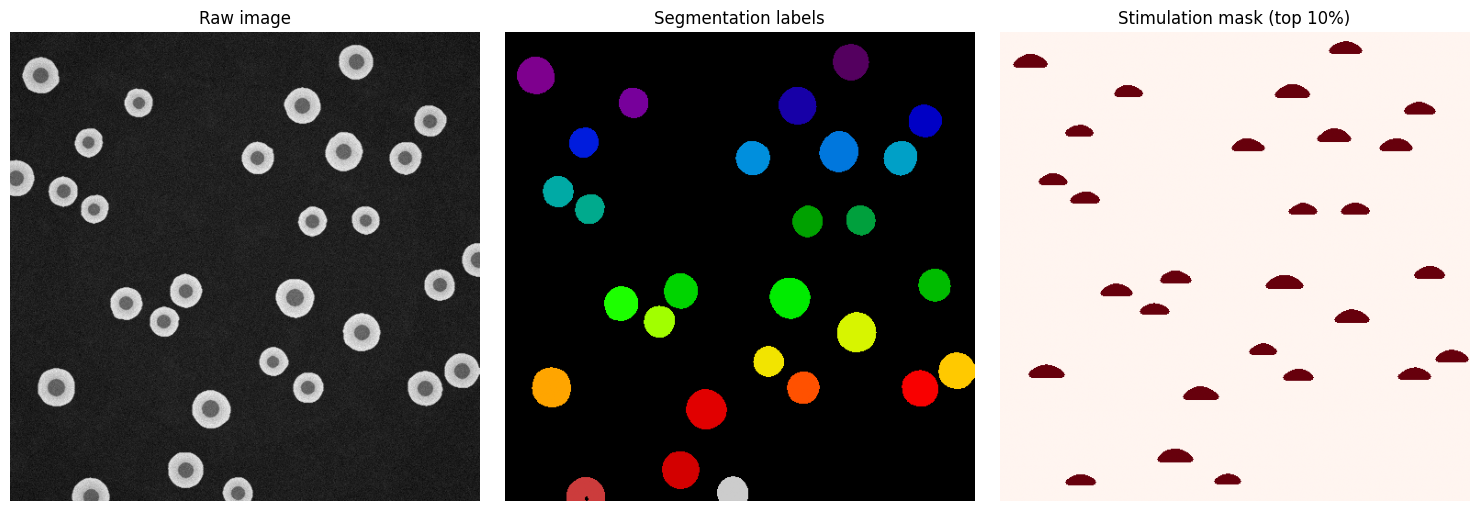

In [28]:
import matplotlib.pyplot as plt

core.setConfig("Channel", "phase-contrast")
core.setXYPosition(256, 256)
core.snapImage()
test_img = core.getImage()

labels_preview = seg.segment(test_img)
mask_preview, _ = stim.get_stim_mask(
    label_images={"labels": labels_preview}, metadata={}
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_img, cmap="gray")
axes[0].set_title("Raw image")
axes[1].imshow(labels_preview, cmap="nipy_spectral")
axes[1].set_title("Segmentation labels")
axes[2].imshow(mask_preview, cmap="Reds")
axes[2].set_title("Stimulation mask (top 10%)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Build acquisition events using RTMEvent + make_acquisition()

50 frames, stimulation active on frames 5–49.

In [29]:
from rtm_pymmcore.core.utils import make_acquisition, events_to_dataframe

n_frames = 40
stim_start = 5
stim_end = 40

events = make_acquisition(
    n_frames=n_frames,
    channels=[Channel(name="phase-contrast", exposure=50)],
    positions=[(256.0, 256.0, 0.0)],
    time_interval=0.4,
    stim_channels=[Channel(name="phase-contrast", exposure=100, power=10)],
    stim_frames=range(stim_start, stim_end),
    metadata={"treatment_name": "top-edge-stim"},
)

df_summary = events_to_dataframe(events)
print(f"{len(events)} RTMEvents created")
df_summary.head()

40 RTMEvents created


,fov,timestep,time,x_pos,y_pos,z_pos,channels,stim_channels,stim,treatment_name,stim_power,stim_exposure
0,0,0,0.0,256.0,256.0,0.0,"({'name': 'phase-contrast', 'exposure': 50, 'g...",(),False,top-edge-stim,NaN,NaN
1,0,1,0.4,256.0,256.0,0.0,"({'name': 'phase-contrast', 'exposure': 50, 'g...",(),False,top-edge-stim,NaN,NaN
2,0,2,0.8,256.0,256.0,0.0,"({'name': 'phase-contrast', 'exposure': 50, 'g...",(),False,top-edge-stim,NaN,NaN
3,0,3,1.2,256.0,256.0,0.0,"({'name': 'phase-contrast', 'exposure': 50, 'g...",(),False,top-edge-stim,NaN,NaN
4,0,4,1.6,256.0,256.0,0.0,"({'name': 'phase-contrast', 'exposure': 50, 'g...",(),False,top-edge-stim,NaN,NaN


## Run experiment

In [30]:
import sys, io, logging, time as _time
from tqdm.auto import tqdm
from rtm_pymmcore.core.data_structures import ImgType

n_total = len(events)
pbar = tqdm(total=n_total, desc="Experiment", unit="frames")
_frame_count = [0]
_t0 = [None]           # wall-clock start (set on first frame)
_max_delay = [0.0]     # track worst-case delay
_late_frames = [0]     # count of frames that arrived late

# Frames arriving more than this many seconds late trigger a warning
_LATE_THRESHOLD = 0.5

def _on_frame(img, event):
    md = event.metadata or {}
    if md.get("img_type") != ImgType.IMG_RAW:
        return

    _frame_count[0] += 1
    pbar.update(1)

    # Clear the SLM mask on non-stim frames so stimulation doesn't persist
    if not md.get("stim", False):
        GLOBAL_BRIDGE.set_slm_mask(None)

    # --- Timing check ---
    now = _time.time()
    if _t0[0] is None:
        _t0[0] = now  # first imaging frame = reference
    expected = md.get("time", 0)
    elapsed = now - _t0[0]
    delay = elapsed - expected
    _max_delay[0] = max(_max_delay[0], delay)
    late = ""
    if delay > _LATE_THRESHOLD:
        _late_frames[0] += 1
        late = f"  LATE +{delay:.1f}s"

    fov = md.get("fov", 0)
    n_cells = mic.analyzer.get_fov_state(fov).n_cells_latest
    ts = md.get("timestep", 0)
    pbar.set_postfix_str(
        f"frame {ts+1}/{n_total},  cells={n_cells},  delay={delay:+.2f}s{late}"
    )

core.mda.events.frameReady.connect(_on_frame)

# Suppress verbose per-frame logs from pipeline and pymmcore-plus
_stdout = sys.stdout
sys.stdout = io.StringIO()
_mda_logger = logging.getLogger("pymmcore-plus")
_prev_level = _mda_logger.level
_mda_logger.setLevel(logging.WARNING)
try:
    mic.run_experiment(events, stim_mode="previous")
    mic.post_experiment()
    mic.analyzer.shutdown(wait=True)
finally:
    sys.stdout = _stdout
    _mda_logger.setLevel(_prev_level)
    try:
        core.mda.events.frameReady.disconnect(_on_frame)
    except Exception:
        pass
    pbar.close()

# Print timing summary
print(f"\nTiming summary:")
print(f"  Max delay: {_max_delay[0]:.2f}s")
print(f"  Late frames (>{_LATE_THRESHOLD}s): {_late_frames[0]}/{n_total}")
if _late_frames[0] > 0:
    print(f"  WARNING: {_late_frames[0]} frames could not keep up with requested timing."
          f" Consider increasing time_interval or reducing FOV count.")

Experiment:   0%|          | 0/40 [00:00<?, ?frames/s]


Timing summary:
  Max delay: 0.15s
  Late frames (>0.5s): 0/40


## Visualize results

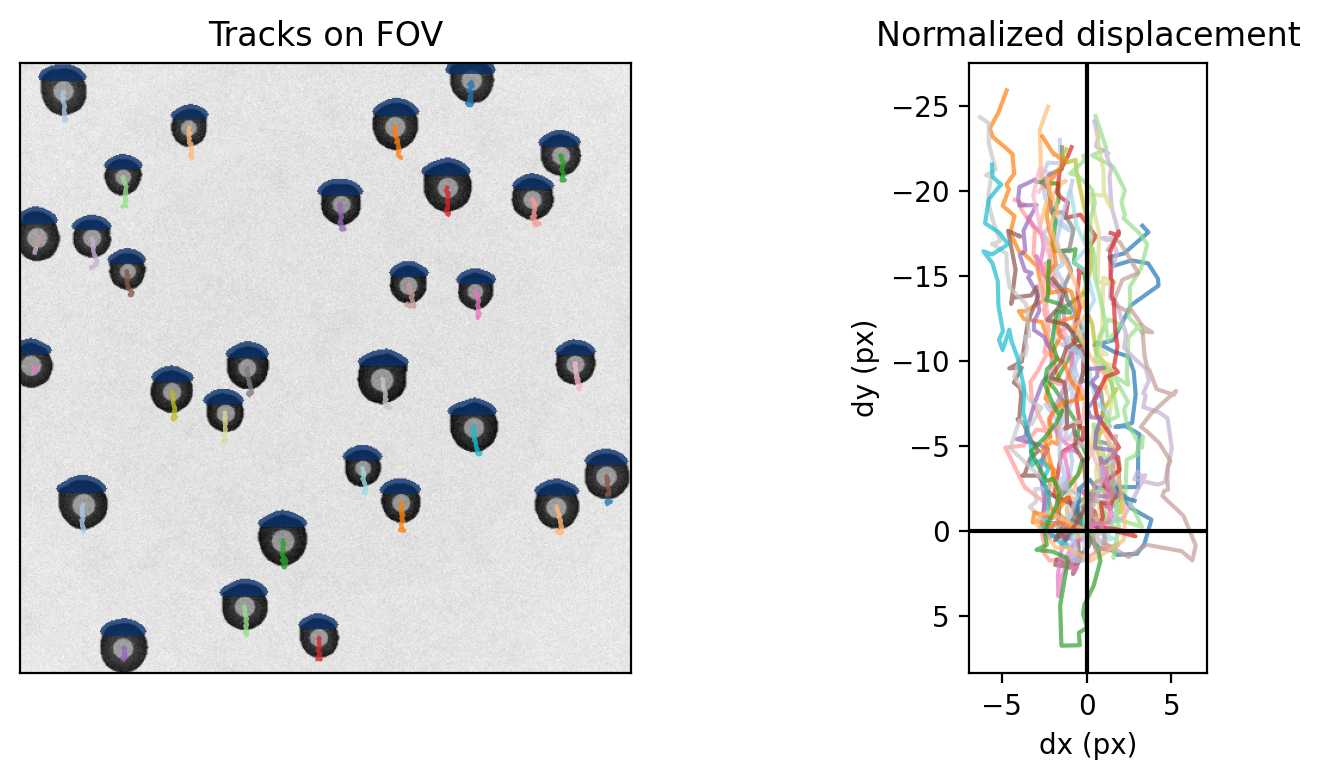

In [39]:
import pandas as pd
import tifffile
from glob import glob

tracks = pd.read_parquet(os.path.join(path, "tracks", "0_latest.parquet"))
particles = tracks["particle"].unique()

fig, axes = plt.subplots(1, 2, figsize=(8, 4),dpi = 200)

# --- Left: FOV overlay ---
ax = axes[0]
raw_files = sorted(glob(os.path.join(path, "raw", "*.tiff")))
last_img = tifffile.imread(raw_files[-1])
if last_img.ndim == 3:
    last_img = last_img[0]
ax.imshow(last_img, cmap="gray_r")

stim_files = sorted(glob(os.path.join(path, "stim_mask", "*.tiff")))
# Find the last non-zero stim mask
stim_mask_img = None
for sf in reversed(stim_files):
    candidate = tifffile.imread(sf)
    if candidate.any():
        stim_mask_img = candidate
        break
if stim_mask_img is not None:
    stim_overlay = np.ma.masked_where(stim_mask_img == 0, stim_mask_img)
    ax.imshow(stim_overlay, cmap="Blues", alpha=0.8, vmin=0, vmax=1)

ax.set_xticks([])
ax.set_yticks([])

cmap = plt.cm.tab20
for i, pid in enumerate(particles):
    t = tracks[tracks["particle"] == pid].sort_values("timestep")
    ax.plot(t["y"], t["x"], color=cmap(i % 20), lw=1.5, alpha=0.8)
ax.set_title("Tracks on FOV")


# --- Right: normalized displacement plot ---
ax = axes[1]

for i, pid in enumerate(particles):
    t = tracks[tracks["particle"] == pid].sort_values("timestep")
    x0, y0 = t.iloc[0]["x"], t.iloc[0]["y"]
    ax.plot(t["y"] - y0, t["x"] - x0, color=cmap(i % 20), alpha=0.7)
ax.set_xlabel("dx (px)")
ax.set_ylabel("dy (px)")
ax.set_title("Normalized displacement")
ax.set_aspect("equal")
ax.axhline(0, color="k")
ax.axvline(0, color="k")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Export stimulation overlay video

In [20]:
import imageio.v3 as iio

raw_files = sorted(glob(os.path.join(path, "raw", "*.tiff")))
stim_files = sorted(glob(os.path.join(path, "stim_mask", "*.tiff")))

frames = []
for raw_f, stim_f in zip(raw_files, stim_files):
    raw = tifffile.imread(raw_f)
    if raw.ndim == 3:
        raw = raw[0]
    stim = tifffile.imread(stim_f)

    # Normalize + invert (gray_r style) → uint8
    lo, hi = float(raw.min()), float(raw.max())
    raw_u8 = (255 - (raw - lo) / (hi - lo + 1e-8) * 255).astype(np.uint8)

    # Grayscale → RGB
    rgb = np.stack([raw_u8, raw_u8, raw_u8], axis=-1)

    # Blue overlay where stim mask is active
    mask = stim > 0
    if mask.any():
        alpha = 0.5
        blue = np.array([50, 120, 255], dtype=np.float32)
        rgb[mask] = (rgb[mask].astype(np.float32) * (1 - alpha) + blue * alpha).astype(np.uint8)

    frames.append(rgb)

output_mp4 = os.path.join(path, "stimulation_overlay.mp4")
iio.imwrite(output_mp4, np.stack(frames), fps=10, codec="libx264")
print(f"Saved {len(frames)}-frame video to {output_mp4}")

Saved 40-frame video to /tmp/test_optogenetic_sim/stimulation_overlay.mp4
